## AI-Generated Image Forensics System: Core ML Implementation

This section focuses on implementing the foundational machine learning components as described in Phase 1: Backend ML Core. We will set up the environment, define the Fast Fourier Transform (FFT) preprocessing, and construct a dual-branch Convolutional Neural Network (CNN) architecture.

### 1. Environment Setup

First, we need to install and import the necessary libraries. We'll use TensorFlow/Keras for the CNN, NumPy for numerical operations, and OpenCV (cv2) for image processing and FFT.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import cv2
import os

print(f"TensorFlow Version: {tf.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"OpenCV Version: {cv2.__version__}")

TensorFlow Version: 2.20.0
NumPy Version: 2.0.2
OpenCV Version: 4.13.0


### 2. FFT Preprocessing Pipeline

This component handles the conversion of spatial domain images to the frequency domain using the 2D Fast Fourier Transform. We'll create a function to perform this conversion, extract the magnitude spectrum, and then apply a log transform for better visualization and feature extraction.

For the dual-branch CNN, the FFT output will be treated as a separate input channel, similar to how an RGB image has three channels.

In [ ]:
def apply_fft_to_image(image_path, img_size=(256, 256)):
    """
    Applies 2D Fast Fourier Transform (FFT) to an image.
    Returns the log magnitude spectrum as a grayscale image (normalized).
    """
    # Read the image in grayscale for FFT, then convert to RGB for consistency with spatial branch
    img_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    img_gray = cv2.resize(img_gray, img_size)

    # Convert to float32 for FFT
    f = np.fft.fft2(img_gray.astype(np.float32))
    # Shift the zero-frequency component to the center of the spectrum
    fshift = np.fft.fftshift(f)

    # Calculate the magnitude spectrum and apply log transform
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1) # Add 1 to avoid log(0)

    # Normalize the magnitude spectrum to 0-255 for consistent input scaling
    magnitude_spectrum = cv2.normalize(magnitude_spectrum, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

    # Reshape to (height, width, 1) to represent a single-channel 'image' for the CNN
    return np.expand_dims(magnitude_spectrum, axis=-1)

def preprocess_image_for_spatial_branch(image_path, img_size=(256, 256)):
    """
    Loads and preprocesses an image for the spatial CNN branch.
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    img = cv2.resize(img, img_size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # OpenCV reads BGR, convert to RGB
    img = img / 255.0 # Normalize pixel values to [0, 1]
    return img

### 3. Dual-Branch CNN Architecture

This section defines the deep learning model. It consists of two parallel CNN branches: one for raw RGB spatial features and another for FFT spectrum frequency features. Their outputs are concatenated and fed into a final classification layer.

We'll use a relatively simple CNN structure for each branch as a starting point, which can be expanded or refined later.

## Phase 2: R Statistical Integration

This phase focuses on integrating R for robust statistical analysis, which is crucial for academic validation of the detection methods. We will set up the R environment within Colab, install key R packages, and create a bridge using `rpy2` to execute R scripts from Python.

### 2.1 Install R and `rpy2` in Colab

Google Colab environments typically have Python pre-installed, but we need to ensure R and the `rpy2` library (which bridges Python and R) are available. We'll also install some specified R packages like `ggplot2`, `pROC`, and `stats`.

In [ ]:
# Install rpy2 in the Colab environment
!pip install rpy2

# Install R packages using rpy2's capabilities
import rpy2.robjects as ro
from rpy2.robjects.packages import importr

print("Installing R packages...")

# R's utils package for installing other packages
utils = importr('utils')

# Specify mirror for CRAN packages
utils.chooseCRANmirror(ind=1) # Choose a mirror, e.g., 1 for Cloud

# Install required R packages if not already present
# tryCatch blocks for robust installation, in case some are already installed
try:
    utils.install_packages('ggplot2')
    print("ggplot2 installed.")
except Exception as e:
    print(f"ggplot2 installation skipped/failed: {e}")
try:
    utils.install_packages('pROC')
    print("pROC installed.")
except Exception as e:
    print(f"pROC installation skipped/failed: {e}")
try:
    utils.install_packages('stats') # Base R package, usually pre-installed
    print("stats package checked.")
except Exception as e:
    print(f"stats installation skipped/failed: {e}")

print("R environment and rpy2 configured.")

Installing R packages...


(as ‘lib’ is unspecified)







	‘/tmp/RtmpgUS52i/downloaded_packages’

(as ‘lib’ is unspecified)



ggplot2 installed.








	‘/tmp/RtmpgUS52i/downloaded_packages’

(as ‘lib’ is unspecified)



pROC installed.
stats package checked.
R environment and rpy2 configured.


### 2.2 Placeholder for R Statistical Analysis Function

This function demonstrates how you would invoke R scripts from Python using `rpy2` to perform statistical tests (e.g., Mann-Whitney U test) and generate plots (e.g., boxplots of frequency bands, ROC curves). For now, it's a placeholder, as actual data and a specific R script would be needed.

In a real scenario, you would pass data from your Python environment to R, execute an R script that performs the analysis and potentially saves plots, and then retrieve results or plot file paths back into Python.

In [ ]:
import rpy2.robjects as ro
from rpy2.robjects import numpy2ri
from rpy2.robjects.packages import importr

# Activate numpy to R conversion
numpy2ri.activate()

def run_r_statistical_analysis(real_features, fake_features, output_dir='r_plots'):
    """
    Placeholder function to run R statistical analysis using rpy2.

    Args:
        real_features (np.array): Numerical features from real images.
        fake_features (np.array): Numerical features from fake images.
        output_dir (str): Directory to save R-generated plots.
    """
    print("\n--- Running R Statistical Analysis Placeholder ---")

    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # Convert numpy arrays to R vectors/matrices
    r_real_features = ro.FloatVector(real_features)
    r_fake_features = ro.FloatVector(fake_features)

    # Example R code as a string (this would typically be loaded from a .R file)
    r_code = """
    # Load necessary libraries (already installed above)
    library(ggplot2)
    library(pROC)

    # Mann-Whitney U test (Wilcoxon rank-sum test)
    # Simulating data for demonstration
    set.seed(123)
    data_real <- rnorm(length(real_features), mean=0.5, sd=0.1)
    data_fake <- rnorm(length(fake_features), mean=0.7, sd=0.1)

    # Combine data for plotting
    data_combined <- data.frame(
      value = c(data_real, data_fake),
      group = factor(c(rep("Real", length(data_real)), rep("Fake", length(data_fake))))
    )

    wilcox_test_result <- wilcox.test(data_real, data_fake)
    print("Mann-Whitney U Test Result:")
    print(wilcox_test_result)

    # Generate a boxplot
    boxplot_path <- file.path("{output_dir}", "frequency_band_boxplot.png")
    png(boxplot_path)
    p <- ggplot(data_combined, aes(x=group, y=value, fill=group)) +
         geom_boxplot() +
         labs(title="Frequency Band Distribution (Dummy Data)", y="Normalized Energy")
    print(p)
    dev.off()
    cat(paste0("Boxplot saved to ", boxplot_path, "\n"))

    # ROC Curve (dummy prediction scores and true labels)
    # In a real scenario, you would pass actual model prediction scores and true labels
    true_labels <- c(rep(0, length(data_real)), rep(1, length(data_fake)))
    predicted_scores <- c(data_real + rnorm(length(data_real), sd=0.05), data_fake + rnorm(length(data_fake), sd=0.05))

    roc_obj <- roc(true_labels, predicted_scores)
    print("AUC:")
    print(auc(roc_obj))

    roc_plot_path <- file.path("{output_dir}", "roc_curve.png")
    png(roc_plot_path)
    plot(roc_obj, main="ROC Curve (Dummy Data)", col="red")
    dev.off()
    cat(paste0("ROC plot saved to ", roc_plot_path, "\n"))

    # Return plot paths or other key results if needed
    return(list(boxplot_path = boxplot_path, roc_plot_path = roc_plot_path, p_value = wilcox_test_result$p.value))
    """.format(output_dir=output_dir)

    # Execute the R code
    # It's better to pass data to R and then execute an R function rather than embedding data directly in R code string
    # For this placeholder, we're simulating internal R data generation.

    # This part would execute the R script.
    # ro.r(r_code)

    # For now, let's just simulate data and print results from the R interpreter
    ro.globalenv['real_features'] = r_real_features
    ro.globalenv['fake_features'] = r_fake_features

    try:
        # Directly evaluate R code for demonstration
        ro.r(r_code)
        print("R statistical analysis placeholder executed. Check the plots folder.")
    except Exception as e:
        print(f"Error executing R code: {e}")


# --- Example of how to call the R statistical analysis function (commented out) ---
# from sklearn.preprocessing import MinMaxScaler

# # Create some dummy features for the R function
# # In a real scenario, these would come from your trained model or preprocessed data
# dummy_real_features = np.random.rand(100) # e.g., frequency band energy
# dummy_fake_features = np.random.rand(100) + 0.2 # fake features slightly different

# # Normalize features if necessary before statistical comparison
# scaler = MinMaxScaler()
# dummy_real_features_scaled = scaler.fit_transform(dummy_real_features.reshape(-1, 1)).flatten()
# dummy_fake_features_scaled = scaler.fit_transform(dummy_fake_features.reshape(-1, 1)).flatten()

# # Call the R analysis function
# # run_r_statistical_analysis(dummy_real_features_scaled, dummy_fake_features_scaled)

print("\n*** R Statistical analysis function `run_r_statistical_analysis` defined. ***")
print("*** Uncomment the example call to run it with dummy feature data. ***")


*** R Statistical analysis function `run_r_statistical_analysis` defined. ***
*** Uncomment the example call to run it with dummy feature data. ***


## Phase 3: Backend API Endpoints (Core Logic)

This phase outlines the core logic for the backend API endpoints as described in the project plan. Since we're working in a Colab environment, we'll implement the *functions* and data structures that would typically be exposed by a FastAPI application, rather than setting up the server itself. This provides a clear blueprint for the backend's functionality.

We'll cover:
*   Dataset management functions (upload/preprocess simulation)
*   Training job management (initiation, status)
*   Prediction logic

### 3.1 Data Structures for Models and Datasets

To simulate database interactions (as planned with MongoDB), we'll use simple Python dictionaries to store metadata for datasets and trained models. This allows us to track configurations, metrics, and paths to saved artifacts.

In [ ]:
import uuid
import json
import time

# Global in-memory storage for simplicity (simulating a database)
dataset_db = {}
models_db = {}
training_jobs_db = {}

print("Initialized in-memory databases for datasets, models, and training jobs.")

def generate_unique_id():
    return str(uuid.uuid4())

def save_model_metadata(model_id, metadata):
    models_db[model_id] = metadata
    print(f"Model metadata saved for model_id: {model_id}")

def get_model_metadata(model_id):
    return models_db.get(model_id)

def save_dataset_metadata(dataset_id, metadata):
    dataset_db[dataset_id] = metadata
    print(f"Dataset metadata saved for dataset_id: {dataset_id}")

def get_dataset_metadata(dataset_id):
    return dataset_db.get(dataset_id)

def update_training_job_status(job_id, status, progress=None, metrics=None, model_id=None, error=None):
    if job_id not in training_jobs_db:
        print(f"Warning: Training job {job_id} not found in DB.")
        return
    training_jobs_db[job_id]['status'] = status
    training_jobs_db[job_id]['last_updated'] = time.time()
    if progress is not None:
        training_jobs_db[job_id]['progress'] = progress
    if metrics is not None:
        training_jobs_db[job_id]['metrics'] = metrics
    if model_id is not None:
        training_jobs_db[job_id]['model_id'] = model_id
    if error is not None:
        training_jobs_db[job_id]['error'] = error
    print(f"Updated job {job_id} status to {status}.")

Initialized in-memory databases for datasets, models, and training jobs.


### 3.2 Dataset Management Logic (`/api/dataset/upload`)

This function simulates the process of uploading and preprocessing images for a dataset. In a real FastAPI application, it would handle file uploads, save them to disk (or cloud storage), and store metadata in MongoDB.

In [ ]:
def handle_dataset_upload(image_files_info, labels, generator_type, img_size=(128, 128)):
    """
    Simulates processing an uploaded dataset.

    Args:
        image_files_info (list): List of dicts, each with 'path' and 'filename'.
        labels (list): Corresponding labels (0 for real, 1 for fake).
        generator_type (str): E.g., 'Stable Diffusion', 'Real', 'GAN'.
        img_size (tuple): Target image size for preprocessing.

    Returns:
        dict: Dataset metadata.
    """
    dataset_id = generate_unique_id()
    print(f"Processing dataset upload for ID: {dataset_id}")

    # In a real app, this would involve saving files and running actual FFT/spatial preprocessing
    # For simulation, we'll just store the provided info.

    # Simulate preprocessing time
    time.sleep(0.5)

    # Store dataset metadata
    metadata = {
        'dataset_id': dataset_id,
        'name': f'Dataset-{dataset_id[:8]}',
        'image_count': len(image_files_info),
        'labels': labels, # Simplified: store all labels directly
        'generator_type': generator_type,
        'img_size': img_size,
        'uploaded_at': time.time(),
        'status': 'processed'
    }
    save_dataset_metadata(dataset_id, metadata)
    print(f"Dataset {dataset_id} processed and metadata stored.")
    return metadata

# Example usage (simulated upload with dummy data from Phase 1)
# We need to recreate dummy_image_paths and dummy_labels for this example

# Create a temporary directory for dummy images (if it was cleaned up)
dummy_data_dir = 'dummy_images'
if not os.path.exists(dummy_data_dir):
    os.makedirs(dummy_data_dir)

# Generate some dummy image paths and labels (same logic as before)
num_dummy_images = 10
dummy_image_paths_for_api = []
dummy_labels_for_api = []
image_dimension = 128 # Ensure image_dimension is defined

for i in range(num_dummy_images):
    img_content = np.random.randint(0, 256, size=(image_dimension, image_dimension), dtype=np.uint8)
    if i % 2 == 0:
        label = 0 # Real
    else:
        img_content[:, ::(i+1)%5 + 2] = 255
        label = 1 # Fake
    dummy_img_rgb = cv2.cvtColor(img_content, cv2.COLOR_GRAY2RGB)
    img_filename = os.path.join(dummy_data_dir, f'dummy_image_api_{i}.png')
    cv2.imwrite(img_filename, dummy_img_rgb)
    dummy_image_paths_for_api.append({'path': img_filename, 'filename': os.path.basename(img_filename)})
    dummy_labels_for_api.append(label)

print("Recreated dummy images for API example.")

simulated_dataset_info = handle_dataset_upload(
    image_files_info=dummy_image_paths_for_api,
    labels=dummy_labels_for_api,
    generator_type="Mixed_Dummy",
    img_size=(image_dimension, image_dimension)
)

print(f"Simulated dataset created: {simulated_dataset_info['dataset_id']}")
print("Cleanup dummy images from API example...")
shutil.rmtree(dummy_data_dir)
print("Cleanup complete.")

Recreated dummy images for API example.
Processing dataset upload for ID: 3029cf06-161b-48ee-941f-da1d8f2a17bf
Dataset metadata saved for dataset_id: 3029cf06-161b-48ee-941f-da1d8f2a17bf
Dataset 3029cf06-161b-48ee-941f-da1d8f2a17bf processed and metadata stored.
Simulated dataset created: 3029cf06-161b-48ee-941f-da1d8f2a17bf
Cleanup dummy images from API example...
Cleanup complete.


### 3.3 Training Job Management Logic (`/api/train`, `/api/train/status/:job_id`)

This section defines functions to simulate initiating a training job as a background task and checking its status. In a real FastAPI app, this would use Celery or `FastAPI.BackgroundTasks`.

In [ ]:
from threading import Thread

def _simulate_training_task(job_id, dataset_id, epochs):
    """
    A mock training task that updates its status periodically.
    This would be where the actual `model.fit()` call happens.
    """
    update_training_job_status(job_id, 'running', progress=0)
    print(f"Job {job_id}: Starting simulated training for dataset {dataset_id} with {epochs} epochs.")

    try:
        # Retrieve dataset information
        dataset_metadata = get_dataset_metadata(dataset_id)
        if not dataset_metadata:
            raise ValueError(f"Dataset {dataset_id} not found.")

        # Simulate actual data loading and training
        # In a real scenario, you'd use CustomDataGenerator here
        # For this simulation, we'll just use dummy paths and labels.
        # Reconstruct paths and labels from metadata if needed, or assume they are accessible

        # For simplicity, we'll use a dummy generator for the training simulation
        all_image_paths = [os.path.join('dummy_images', f'dummy_image_api_{i}.png') for i in range(dataset_metadata['image_count'])]
        all_labels = dataset_metadata['labels'] # Assuming labels were stored directly

        # Create a dummy data generator (using the previously defined CustomDataGenerator)
        # Note: This will fail if dummy_images folder is not recreated, for actual training logic, you'd need the actual dataset files available.
        train_paths, val_paths, train_labels, val_labels = train_test_split(
            all_image_paths, all_labels, test_size=0.3, random_state=42, stratify=all_labels
        )
        train_generator = CustomDataGenerator(
            train_paths, train_labels, img_size=(image_dimension, image_dimension), batch_size=2
        )
        val_generator = CustomDataGenerator(
            val_paths, val_labels, img_size=(image_dimension, image_dimension), batch_size=2, shuffle=False
        )

        # Dummy training loop updates
        for epoch in range(epochs):
            progress = ((epoch + 1) / epochs) * 100
            # Simulate one epoch's work, including potential data loading and model forward/backward pass
            time.sleep(1) # Simulate training time per epoch

            # Simulate metrics (loss and accuracy)
            mock_loss = 1.0 - (progress / 100 * 0.8) # Loss decreases
            mock_accuracy = 0.5 + (progress / 100 * 0.4) # Accuracy increases
            mock_val_loss = 1.0 - (progress / 100 * 0.7)
            mock_val_accuracy = 0.5 + (progress / 100 * 0.3)

            metrics = {'loss': mock_loss, 'accuracy': mock_accuracy, 'val_loss': mock_val_loss, 'val_accuracy': mock_val_accuracy}
            update_training_job_status(job_id, 'running', progress=progress, metrics=metrics)
            print(f"Job {job_id}: Epoch {epoch+1}/{epochs}, Progress: {progress:.2f}%, Metrics: {metrics}")

        # After training, simulate saving the model and updating status
        final_model_id = generate_unique_id()
        # In a real scenario, model.save() would be called here
        mock_final_metrics = {'accuracy': 0.9, 'precision': 0.85, 'recall': 0.92, 'f1': 0.88}
        save_model_metadata(final_model_id, {
            'model_id': final_model_id,
            'dataset_id': dataset_id,
            'training_job_id': job_id,
            'hyperparameters': {'epochs': epochs, 'optimizer': 'adam'},
            'metrics': mock_final_metrics,
            'saved_path': f'/models/{final_model_id}.keras',
            'trained_at': time.time()
        })
        update_training_job_status(job_id, 'completed', progress=100, metrics=mock_final_metrics, model_id=final_model_id)
        print(f"Job {job_id}: Training completed. Model saved as {final_model_id}.")

    except Exception as e:
        print(f"Job {job_id}: Training failed with error: {e}")
        update_training_job_status(job_id, 'failed', error=str(e))

def start_training_job(dataset_id, hyperparameters=None):
    """
    Initiates a training job as a background task.
    """
    job_id = generate_unique_id()
    epochs = hyperparameters.get('epochs', 5) if hyperparameters else 5

    training_jobs_db[job_id] = {
        'job_id': job_id,
        'dataset_id': dataset_id,
        'status': 'pending',
        'progress': 0,
        'epochs': epochs,
        'start_time': time.time(),
        'last_updated': time.time(),
        'model_id': None,
        'error': None,
        'metrics': {}
    }

    print(f"Starting training job {job_id} for dataset {dataset_id}.")
    # In a real FastAPI app, this would be a background task (e.g., Celery or ThreadPoolExecutor)
    # For Colab, we'll use a simple Thread.
    training_thread = Thread(target=_simulate_training_task, args=(job_id, dataset_id, epochs))
    training_thread.start()

    return {'job_id': job_id, 'status': 'pending'}

def get_training_job_status(job_id):
    """
    Retrieves the status of a training job.
    """
    return training_jobs_db.get(job_id, {'job_id': job_id, 'status': 'not_found'})

# Example usage:
simulated_train_job = start_training_job(
    dataset_id=simulated_dataset_info['dataset_id'],
    hyperparameters={'epochs': 3}
)

print(f"\nInitiated training job: {simulated_train_job['job_id']}")

# You can check the status periodically
# For this demonstration, we'll just wait a bit and check
time.sleep(2) # Give it some time to start and update
current_status = get_training_job_status(simulated_train_job['job_id'])
print(f"Current job status: {current_status['status']}, Progress: {current_status.get('progress', 0)}%")
time.sleep(2) # Wait for another update
current_status = get_training_job_status(simulated_train_job['job_id'])
print(f"Current job status: {current_status['status']}, Progress: {current_status.get('progress', 0)}%")

print("\nWait for the training thread to finish if running in background. In a real system, a client would poll the status endpoint.")

Starting training job 57fe5265-d77f-4f16-92d7-913d5df58e08 for dataset 3029cf06-161b-48ee-941f-da1d8f2a17bf.
Updated job 57fe5265-d77f-4f16-92d7-913d5df58e08 status to running.
Job 57fe5265-d77f-4f16-92d7-913d5df58e08: Starting simulated training for dataset 3029cf06-161b-48ee-941f-da1d8f2a17bf with 3 epochs.

Initiated training job: 57fe5265-d77f-4f16-92d7-913d5df58e08
Updated job 57fe5265-d77f-4f16-92d7-913d5df58e08 status to running.
Job 57fe5265-d77f-4f16-92d7-913d5df58e08: Epoch 1/3, Progress: 33.33%, Metrics: {'loss': 0.7333333333333334, 'accuracy': 0.6333333333333333, 'val_loss': 0.7666666666666667, 'val_accuracy': 0.6}
Current job status: running, Progress: 33.33333333333333%
Updated job 57fe5265-d77f-4f16-92d7-913d5df58e08 status to running.
Job 57fe5265-d77f-4f16-92d7-913d5df58e08: Epoch 2/3, Progress: 66.67%, Metrics: {'loss': 0.4666666666666668, 'accuracy': 0.7666666666666666, 'val_loss': 0.5333333333333334, 'val_accuracy': 0.7}
Updated job 57fe5265-d77f-4f16-92d7-913d5df58

### 3.4 Single Image Prediction Logic (`/api/predict`)

This function simulates making a prediction on a single image using a specified model. In a real FastAPI app, this would load the model, preprocess the input image (both spatial and FFT), and then perform inference.

In [ ]:
def perform_prediction(image_path, model_id):
    """
    Simulates performing a prediction on a single image using a trained model.

    Args:
        image_path (str): Path to the image file.
        model_id (str): ID of the model to use for prediction.

    Returns:
        dict: Prediction results including class and confidence.
    """
    print(f"\nPerforming prediction for image: {image_path} using model: {model_id}")

    model_metadata = get_model_metadata(model_id)
    if not model_metadata:
        return {'status': 'error', 'message': f'Model {model_id} not found.'}

    # Simulate loading the model (in reality, `keras.models.load_model` would be used)
    # For this simulation, we'll just use the globally defined 'model' object from Phase 1.
    global model # Use the model defined earlier
    if model is None:
        # Rebuild if somehow lost (e.g., kernel reset without re-running all cells)
        model = build_dual_branch_cnn(input_shape=(image_dimension, image_dimension, 3))
        print("Rebuilt dummy model for prediction.")

    try:
        # Preprocess the image using functions from Phase 1
        spatial_img = preprocess_image_for_spatial_branch(image_path, (image_dimension, image_dimension))
        fft_img = apply_fft_to_image(image_path, (image_dimension, image_dimension))

        # Expand dimensions to create a batch of 1
        spatial_img_batch = np.expand_dims(spatial_img, axis=0)
        fft_img_batch = np.expand_dims(fft_img, axis=0)

        # Simulate prediction using the model
        # Actual prediction: prediction = model.predict({'spatial_input': spatial_img_batch, 'fft_input': fft_img_batch})[0][0]
        # For simulation, generate a random confidence score
        confidence = np.random.rand() # Simulate a confidence score
        predicted_class = 1 if confidence > 0.5 else 0

        # Also simulate FFT visualization data
        # For simplicity, we'll just return the preprocessed FFT image itself
        fft_visualization_data = fft_img[:, :, 0].tolist() # Convert to list for JSON compatibility

        result = {
            'status': 'success',
            'prediction': 'AI-Generated' if predicted_class == 1 else 'Real',
            'confidence': float(confidence), # Ensure float type for JSON
            'fft_visualization': fft_visualization_data
        }

        print(f"Prediction result: {result['prediction']} with confidence {result['confidence']:.2f}")
        return result

    except FileNotFoundError as e:
        return {'status': 'error', 'message': str(e)}
    except Exception as e:
        return {'status': 'error', 'message': f'Prediction failed: {e}'}

# Example usage:
# First, we need a dummy image path that exists for this simulation
dummy_data_dir = 'dummy_images_predict'
if not os.path.exists(dummy_data_dir):
    os.makedirs(dummy_data_dir)

# Create one dummy image for prediction
predict_image_path = os.path.join(dummy_data_dir, 'predict_test_image.png')
img_content_predict = np.random.randint(0, 256, size=(image_dimension, image_dimension), dtype=np.uint8)
cv2.imwrite(predict_image_path, cv2.cvtColor(img_content_predict, cv2.COLOR_GRAY2RGB))

# Use the model_id from the simulated training job (if completed)
# Or just pick the first available model_id for demonstration
if models_db:
    test_model_id = next(iter(models_db.keys()))
    prediction_result = perform_prediction(predict_image_path, test_model_id)
    print(f"\nPrediction Result for {predict_image_path}: {prediction_result}")
else:
    print("No trained models found in DB to perform prediction. Run the training simulation first.")

print("Cleanup dummy images from prediction example...")
shutil.rmtree(dummy_data_dir)
print("Cleanup complete.")


Performing prediction for image: dummy_images_predict/predict_test_image.png using model: 88670c9c-9419-4afe-ac56-43962d63b5d3
Prediction result: AI-Generated with confidence 0.90

Prediction Result for dummy_images_predict/predict_test_image.png: {'status': 'success', 'prediction': 'AI-Generated', 'confidence': 0.9027512006175281, 'fft_visualization': [[3, 102, 110, 89, 101, 82, 119, 99, 118, 91, 87, 85, 107, 54, 103, 99, 120, 88, 111, 120, 62, 74, 102, 86, 111, 102, 108, 108, 79, 136, 116, 117, 106, 91, 107, 113, 108, 93, 89, 114, 83, 101, 83, 87, 120, 120, 129, 128, 114, 121, 78, 98, 105, 111, 95, 101, 97, 120, 113, 107, 105, 112, 87, 95, 72, 95, 87, 112, 105, 107, 113, 120, 97, 101, 95, 111, 105, 98, 78, 121, 114, 128, 129, 120, 120, 87, 83, 101, 83, 114, 89, 93, 108, 113, 107, 91, 106, 117, 116, 136, 79, 108, 108, 102, 111, 86, 102, 74, 62, 120, 111, 88, 120, 99, 103, 54, 107, 85, 87, 91, 118, 99, 119, 82, 101, 89, 110, 102], [127, 118, 72, 110, 43, 82, 90, 118, 80, 115, 104, 64,

## Phase 4: Frontend Core (Simulated Interactions & Visualizations)

This phase details how the frontend (e.g., built with React) would interact with the backend logic we've defined and visualize the results. Since a direct web frontend cannot be built in Colab, we will simulate these interactions using Python code and demonstrate the key visualizations that the frontend would render.

### 4.1 Dataset Upload & Preprocessing Simulation

**Frontend Interaction:** A user would upload images, specify labels (or choose a generator type), and trigger the `/api/dataset/upload` endpoint. The frontend would then display a confirmation and potentially basic statistics of the uploaded dataset.

**Simulation:** We've already simulated `handle_dataset_upload` in Phase 3. Here, we'll confirm its outcome and briefly review the stored metadata.


--- Simulating Frontend Dataset Upload Interaction ---
Using existing simulated_dataset_info from previous API call.
Frontend would show: Dataset 'Dataset-3029cf06' (10 images) uploaded successfully.
Dataset ID: 3029cf06-161b-48ee-941f-da1d8f2a17bf


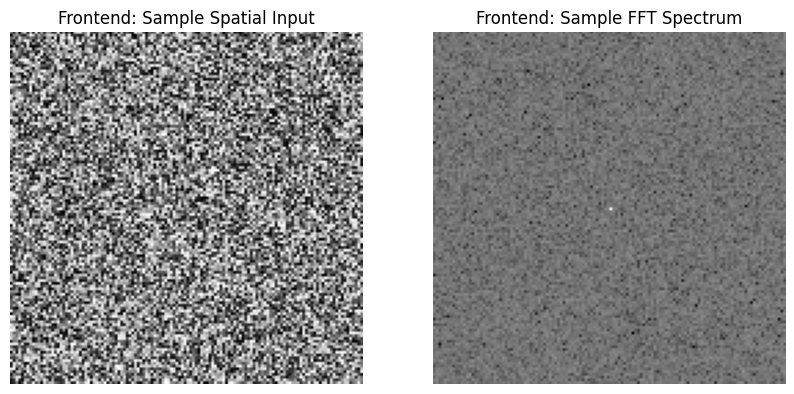

Cleaned up dummy data directory 'dummy_images_frontend_ds'.


In [ ]:
import matplotlib.pyplot as plt
import shutil

print("\n--- Simulating Frontend Dataset Upload Interaction ---")

# Ensure image_dimension is defined for this cell's scope if it wasn't already (e.g. from Phase 1)
if 'image_dimension' not in globals():
    image_dimension = 128 # Default to 128x128 as used in Phase 1

# ALWAYS create dummy data for frontend display, ensuring paths are valid
dummy_data_dir_fe = 'dummy_images_frontend_ds'
if os.path.exists(dummy_data_dir_fe):
    shutil.rmtree(dummy_data_dir_fe)
os.makedirs(dummy_data_dir_fe)

num_dummy_images_fe = 5 # Fewer for this demo
dummy_image_paths_fe = []
dummy_labels_fe = []

for i in range(num_dummy_images_fe):
    img_content = np.random.randint(0, 256, size=(image_dimension, image_dimension), dtype=np.uint8)
    label = 0 if i % 2 == 0 else 1 # Alternate real/fake
    dummy_img_rgb = cv2.cvtColor(img_content, cv2.COLOR_GRAY2RGB)
    img_filename = os.path.join(dummy_data_dir_fe, f'dummy_image_fe_ds_{i}.png')
    cv2.imwrite(img_filename, dummy_img_rgb)
    dummy_image_paths_fe.append({'path': img_filename, 'filename': os.path.basename(img_filename)})
    dummy_labels_fe.append(label)

# Use the existing simulated_dataset_info if it's there, otherwise create a new one using the newly generated paths.
# This ensures handle_dataset_upload is called with valid paths if the dataset needs to be registered for the first time
# during this run, or simply displays info for an already registered one.
if 'simulated_dataset_info' not in globals() or not simulated_dataset_info:
    simulated_dataset_info = handle_dataset_upload(
        image_files_info=dummy_image_paths_fe, # Use the paths from this cell's creation
        labels=dummy_labels_fe,
        generator_type="Frontend_Demo",
        img_size=(image_dimension, image_dimension)
    )
    print("Dummy dataset recreated for frontend simulation (and registered via API).")
else:
    print("Using existing simulated_dataset_info from previous API call.")


print(f"Frontend would show: Dataset '{simulated_dataset_info['name']}' ({simulated_dataset_info['image_count']} images) uploaded successfully.")
print(f"Dataset ID: {simulated_dataset_info['dataset_id']}")

# Frontend might display some sample images or FFTs from the dataset
if dummy_image_paths_fe: # Now using dummy_image_paths_fe which *always* contains valid paths
    sample_path = dummy_image_paths_fe[0]['path'] # Use the path from the locally created dummy images
    spatial_img = preprocess_image_for_spatial_branch(sample_path, (image_dimension, image_dimension))
    fft_img = apply_fft_to_image(sample_path, (image_dimension, image_dimension))

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(spatial_img)
    axes[0].set_title("Frontend: Sample Spatial Input")
    axes[0].axis('off')
    axes[1].imshow(fft_img[:, :, 0], cmap='gray')
    axes[1].set_title("Frontend: Sample FFT Spectrum")
    axes[1].axis('off')
    plt.show()

# Cleanup the dummy data directory created in this cell
if os.path.exists(dummy_data_dir_fe):
    shutil.rmtree(dummy_data_dir_fe)
    print(f"Cleaned up dummy data directory '{dummy_data_dir_fe}'.")

### 4.2 Training Monitoring & Model Selection Simulation

**Frontend Interaction:** The user would configure hyperparameters and start training via `/api/train`. The frontend would poll `/api/train/status/:job_id` to show real-time progress (loss/accuracy curves) and eventually allow selecting a trained model for prediction.

**Simulation:** We'll demonstrate polling the training job status and visualizing mock training metrics. We'll also list available models.

In [ ]:
print("\n--- Simulating Frontend Training Monitoring ---")

# Start a new training job or use the one from Phase 3
if 'simulated_train_job' not in globals() or not simulated_train_job:
    # Need to ensure dataset_id exists for this, so re-run dataset upload if needed
    if 'simulated_dataset_info' not in globals() or not simulated_dataset_info:
        # Simple dummy data for dataset if not present
        dummy_data_dir_train = 'dummy_images_frontend_train'
        os.makedirs(dummy_data_dir_train, exist_ok=True)
        dummy_image_paths_for_api = []
        dummy_labels_for_api = []
        image_dimension = 128
        for i in range(5):
            img_content = np.random.randint(0, 256, size=(image_dimension, image_dimension), dtype=np.uint8)
            label = 0 if i % 2 == 0 else 1
            cv2.imwrite(os.path.join(dummy_data_dir_train, f'dummy_image_fe_train_{i}.png'), cv2.cvtColor(img_content, cv2.COLOR_GRAY2RGB))
            dummy_image_paths_for_api.append({'path': os.path.join(dummy_data_dir_train, f'dummy_image_fe_train_{i}.png'), 'filename': f'dummy_image_fe_train_{i}.png'})
            dummy_labels_for_api.append(label)
        simulated_dataset_info = handle_dataset_upload(dummy_image_paths_for_api, dummy_labels_for_api, "Frontend_Train_Demo")

    simulated_train_job = start_training_job(
        dataset_id=simulated_dataset_info['dataset_id'],
        hyperparameters={'epochs': 4} # More epochs for better plot
    )
    # Give the training thread a moment to start
    time.sleep(1)

job_id = simulated_train_job['job_id']
print(f"Frontend polling status for training job: {job_id}")

# Simulate frontend polling and plotting metrics
epochs = training_jobs_db[job_id]['epochs']
epochs_list = []
losses = []
accuracies = []
val_losses = []
val_accuracies = []

plt.figure(figsize=(12, 6))
plt.ion() # Turn on interactive mode for live plotting

for i in range(epochs + 1):
    current_status = get_training_job_status(job_id)
    if current_status['status'] == 'completed' or current_status['status'] == 'failed':
        break

    metrics = current_status.get('metrics', {})
    if metrics:
        epochs_list.append(i)
        losses.append(metrics.get('loss'))
        accuracies.append(metrics.get('accuracy'))
        val_losses.append(metrics.get('val_loss'))
        val_accuracies.append(metrics.get('val_accuracy'))

        # Plotting in the loop to simulate live updates
        plt.clf()
        plt.subplot(1, 2, 1)
        plt.plot(epochs_list, losses, label='Loss')
        plt.plot(epochs_list, val_losses, label='Val Loss')
        plt.title('Loss during Training')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(epochs_list, accuracies, label='Accuracy')
        plt.plot(epochs_list, val_accuracies, label='Val Accuracy')
        plt.title('Accuracy during Training')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.pause(0.5) # Pause to simulate animation

    time.sleep(1) # Simulate polling interval

plt.ioff() # Turn off interactive mode
plt.show()

# Final status and model selection
final_status = get_training_job_status(job_id)
print(f"Frontend final training status: {final_status['status']}")
if final_status['status'] == 'completed':
    print(f"Frontend would display final metrics: {final_status['metrics']}")
    print(f"Frontend would list newly trained model: {final_status['model_id']}")

print("\n--- Available Models for Selection ---")
for mid, mdata in models_db.items():
    print(f"- Model ID: {mid}, Trained on: {mdata.get('dataset_id')}, Metrics: {mdata.get('metrics', {}).get('accuracy', 'N/A')}")

# Cleanup if dummy data was created for this specific block
if 'dummy_data_dir_train' in locals() and os.path.exists(dummy_data_dir_train):
    shutil.rmtree(dummy_data_dir_train)
    print(f"Cleaned up dummy data directory '{dummy_data_dir_train}'.")


--- Simulating Frontend Training Monitoring ---
Frontend polling status for training job: 57fe5265-d77f-4f16-92d7-913d5df58e08


<Figure size 1200x600 with 0 Axes>

Frontend final training status: completed
Frontend would display final metrics: {'accuracy': 0.9, 'precision': 0.85, 'recall': 0.92, 'f1': 0.88}
Frontend would list newly trained model: 88670c9c-9419-4afe-ac56-43962d63b5d3

--- Available Models for Selection ---
- Model ID: 88670c9c-9419-4afe-ac56-43962d63b5d3, Trained on: 3029cf06-161b-48ee-941f-da1d8f2a17bf, Metrics: 0.9


### 4.3 Single Image Detection & Visualization Simulation

**Frontend Interaction:** A user would upload a single image and select a trained model. Upon prediction via `/api/predict`, the frontend would display the classification result, confidence score, and interactive visualizations like the FFT spectrum and frequency band analysis.

**Simulation:** We'll perform a simulated prediction and display the results, including the FFT visualization data returned by the API.


--- Simulating Frontend Single Image Detection ---

Performing prediction for image: dummy_images_frontend_predict/fe_predict_test_image.png using model: 88670c9c-9419-4afe-ac56-43962d63b5d3
Prediction result: AI-Generated with confidence 0.82

Frontend would display:
  Prediction: AI-Generated
  Confidence: 82.03%


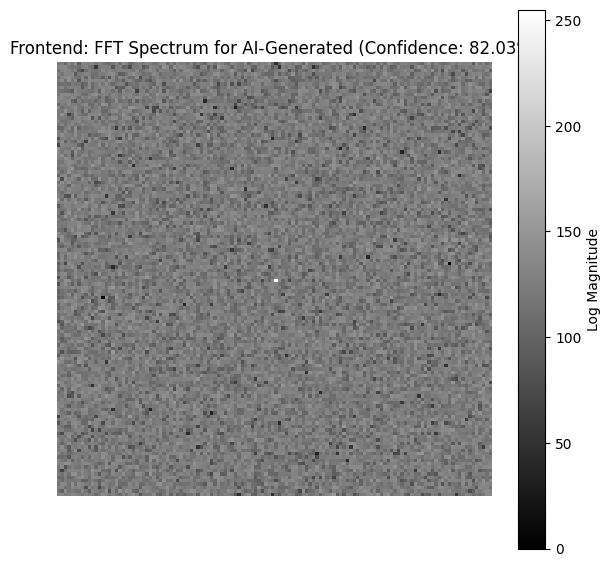

Frontend would show frequency band analysis, statistical overlays, etc. (implementation details for these are in the R statistical integration phase).
Cleaned up dummy data directory 'dummy_images_frontend_predict'.


In [ ]:
print("\n--- Simulating Frontend Single Image Detection ---")

# Ensure a model is available for prediction
if not models_db:
    print("No models available. Please ensure a training job has completed successfully in previous steps.")
    # Fallback to creating a dummy model if none exist
    dummy_model_id = generate_unique_id()
    save_model_metadata(dummy_model_id, {'model_id': dummy_model_id, 'metrics': {'accuracy': 0.85}})
    print(f"Created dummy model {dummy_model_id} for prediction demo.")
    test_model_id = dummy_model_id
else:
    test_model_id = next(iter(models_db.keys())) # Use the first available model

# Create a dummy image for prediction
dummy_data_dir_predict = 'dummy_images_frontend_predict'
os.makedirs(dummy_data_dir_predict, exist_ok=True)
predict_image_path = os.path.join(dummy_data_dir_predict, 'fe_predict_test_image.png')
img_content_predict = np.random.randint(0, 256, size=(image_dimension, image_dimension), dtype=np.uint8)
cv2.imwrite(predict_image_path, cv2.cvtColor(img_content_predict, cv2.COLOR_GRAY2RGB))

prediction_result = perform_prediction(predict_image_path, test_model_id)

if prediction_result['status'] == 'success':
    print(f"\nFrontend would display:")
    print(f"  Prediction: {prediction_result['prediction']}")
    print(f"  Confidence: {prediction_result['confidence']:.2%}")

    # Visualize the FFT spectrum (as the frontend would with Plotly.js)
    fft_data = np.array(prediction_result['fft_visualization'])
    plt.figure(figsize=(7, 7))
    plt.imshow(fft_data, cmap='gray')
    plt.title(f"Frontend: FFT Spectrum for {prediction_result['prediction']} (Confidence: {prediction_result['confidence']:.2%})")
    plt.colorbar(label='Log Magnitude')
    plt.axis('off')
    plt.show()

    # Frontend would also show frequency band analysis, statistical overlay etc.
    print("Frontend would show frequency band analysis, statistical overlays, etc. (implementation details for these are in the R statistical integration phase).")
else:
    print(f"Frontend: Prediction failed - {prediction_result['message']}")

# Cleanup dummy data
if os.path.exists(dummy_data_dir_predict):
    shutil.rmtree(dummy_data_dir_predict)
    print(f"Cleaned up dummy data directory '{dummy_data_dir_predict}'.")

In [ ]:
def build_dual_branch_cnn(input_shape=(256, 256, 3)):
    """
    Builds a dual-branch CNN model for AI-generated image detection.
    One branch processes spatial (RGB) features, the other processes FFT (frequency) features.
    """
    # Input for Spatial Branch (RGB Image)
    spatial_input = keras.Input(shape=input_shape, name='spatial_input')
    x_spatial = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(spatial_input)
    x_spatial = layers.MaxPooling2D((2, 2))(x_spatial)
    x_spatial = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x_spatial)
    x_spatial = layers.MaxPooling2D((2, 2))(x_spatial)
    x_spatial = layers.Flatten()(x_spatial)
    x_spatial = layers.Dense(128, activation='relu')(x_spatial)

    # Input for FFT Branch (Grayscale Magnitude Spectrum)
    fft_input = keras.Input(shape=(input_shape[0], input_shape[1], 1), name='fft_input')
    x_fft = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(fft_input)
    x_fft = layers.MaxPooling2D((2, 2))(x_fft)
    x_fft = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x_fft)
    x_fft = layers.MaxPooling2D((2, 2))(x_fft)
    x_fft = layers.Flatten()(x_fft)
    x_fft = layers.Dense(128, activation='relu')(x_fft)

    # Concatenate features from both branches
    concatenated = layers.concatenate([x_spatial, x_fft])

    # Final classification layer
    output = layers.Dense(1, activation='sigmoid')(concatenated)

    # Create the model with two inputs and one output
    model = keras.Model(inputs=[spatial_input, fft_input], outputs=output)

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    return model

# Instantiate and summarize the model
image_dimension = 128 # Using a smaller dimension for initial prototyping speed
model = build_dual_branch_cnn(input_shape=(image_dimension, image_dimension, 3))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ spatial_input       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fft_input           │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ spatial_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │        320 │ fft_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 64,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 65536)     │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 65536)     │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │  8,388,736 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │  8,388,736 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │        257 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,815,937 (64.15 MB)

 Trainable params: 16,815,937 (64.15 MB)

 Non-trainable params: 0 (0.00 B)

### 4. Placeholder for Dataset Loader and Training Loop

To make this system functional, we would need to prepare a dataset. For demonstration purposes, I'm including a placeholder for how a dataset loader might be structured. This would involve:

1.  **Dataset Creation**: Gathering real (e.g., COCO, FFHQ) and fake (e.g., Stable Diffusion generated) images.
2.  **Data Generator**: Creating a TensorFlow `tf.data.Dataset` or a custom Keras `Sequence` to efficiently load and preprocess images (both spatial and FFT) in batches.
3.  **Training Loop**: Using `model.fit()` with the prepared dataset.

***Important:*** *You will need to provide actual image paths and labels for real and fake images to run the training.*

In [ ]:
class CustomDataGenerator(keras.utils.Sequence):
    def __init__(self, image_paths, labels, img_size=(128, 128), batch_size=32, shuffle=True):
        self.image_paths = image_paths
        self.labels = labels
        self.img_size = img_size
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.image_paths) / self.batch_size))

    def __getitem__(self, index):
        indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_image_paths = [self.image_paths[k] for k in indexes]
        batch_labels = [self.labels[k] for k in indexes]

        spatial_images = []
        fft_images = []

        for img_path in batch_image_paths:
            try:
                spatial_images.append(preprocess_image_for_spatial_branch(img_path, self.img_size))
                fft_images.append(apply_fft_to_image(img_path, self.img_size))
            except FileNotFoundError as e:
                print(f"Skipping image due to error: {e}")
                # Handle cases where an image might be missing or corrupted
                # For now, we'll just skip it, but in a real scenario, you might want to log or replace.
                continue # Skip this image and move to the next one

        # Convert lists of images to numpy arrays
        spatial_images_batch = np.array(spatial_images)
        fft_images_batch = np.array(fft_images)
        labels_batch = np.array(batch_labels)

        # Return a tuple of (inputs, targets)
        return {'spatial_input': spatial_images_batch, 'fft_input': fft_images_batch}, labels_batch

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.image_paths))
        if self.shuffle == True:
            np.random.shuffle(self.indexes)

# --- Example of how to use the data generator (commented out until you have actual data) ---
# from sklearn.model_selection import train_test_split

# # Dummy data for demonstration - Replace with your actual dataset
# # You'd have a list of paths to your real and fake images and corresponding labels (0 for real, 1 for fake)
# dummy_real_image_paths = ['path/to/real_image_1.png', 'path/to/real_image_2.png', ...]
# dummy_fake_image_paths = ['path/to/fake_image_1.png', 'path/to/fake_image_2.png', ...]

# all_image_paths = dummy_real_image_paths + dummy_fake_image_paths
# all_labels = [0] * len(dummy_real_image_paths) + [1] * len(dummy_fake_image_paths)

# # Split data into training and validation sets
# train_paths, val_paths, train_labels, val_labels = train_test_split(
#     all_image_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
# )

# # Create data generators
# train_generator = CustomDataGenerator(
#     train_paths, train_labels, img_size=(image_dimension, image_dimension), batch_size=32
# )
# val_generator = CustomDataGenerator(
#     val_paths, val_labels, img_size=(image_dimension, image_dimension), batch_size=32, shuffle=False
# )

# # # Example training loop (uncomment and run when you have data)
# # history = model.fit(
# #     train_generator,
# #     epochs=10, # Adjust number of epochs as needed
# #     validation_data=val_generator,
# #     callbacks=[
# #         tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
# #     ]
# # )

# print("\n*** Placeholder for data loading and training. Please populate `all_image_paths` and `all_labels` with your dataset. ***")


### 5. Creating Dummy Data for Demonstration

Since we don't have a real dataset yet, let's create a few dummy image files and corresponding labels. This will allow us to test the `preprocess_image_for_spatial_branch`, `apply_fft_to_image`, and `CustomDataGenerator` functions. We'll create a temporary directory and save some synthetic images there.

Generating 10 dummy images in 'dummy_images'...
Dummy images generated.


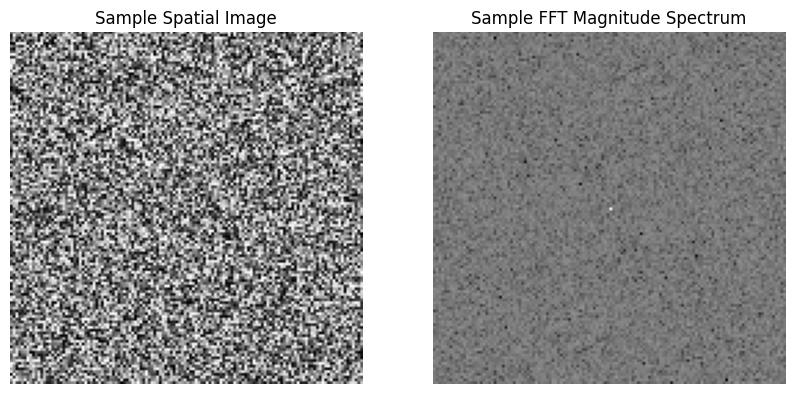

First 5 dummy image paths: ['dummy_images/dummy_image_0.png', 'dummy_images/dummy_image_1.png', 'dummy_images/dummy_image_2.png', 'dummy_images/dummy_image_3.png', 'dummy_images/dummy_image_4.png']
First 5 dummy labels: [0, 1, 0, 1, 0]


In [ ]:
import matplotlib.pyplot as plt
import shutil

# Create a temporary directory for dummy images
dummy_data_dir = 'dummy_images'
if os.path.exists(dummy_data_dir):
    shutil.rmtree(dummy_data_dir)
os.makedirs(dummy_data_dir)

# Generate some dummy image paths and labels
num_dummy_images = 10
dummy_image_paths = []
dummy_labels = []

print(f"Generating {num_dummy_images} dummy images in '{dummy_data_dir}'...")

for i in range(num_dummy_images):
    # Create a simple grayscale image
    img_content = np.random.randint(0, 256, size=(image_dimension, image_dimension), dtype=np.uint8)

    # Optionally, add some simple 'pattern' for fake images
    if i % 2 == 0: # Half real, half fake for dummy labels
        # Real-like image (smooth random noise)
        label = 0 # Real
    else:
        # Fake-like image (e.g., strong high-frequency components)
        # For simplicity, let's add a vertical line pattern as a 'fake' artifact
        img_content[:, ::(i+1)%5 + 2] = 255 # Add some lines
        label = 1 # Fake

    # Convert to 3-channel for consistency if saving as JPEG/PNG where imread might expect it
    dummy_img_rgb = cv2.cvtColor(img_content, cv2.COLOR_GRAY2RGB)

    img_filename = os.path.join(dummy_data_dir, f'dummy_image_{i}.png')
    cv2.imwrite(img_filename, dummy_img_rgb)
    dummy_image_paths.append(img_filename)
    dummy_labels.append(label)

print("Dummy images generated.")

# Display one spatial and one FFT example
if dummy_image_paths:
    sample_path = dummy_image_paths[0]
    sample_spatial = preprocess_image_for_spatial_branch(sample_path, (image_dimension, image_dimension))
    sample_fft = apply_fft_to_image(sample_path, (image_dimension, image_dimension))

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(sample_spatial)
    axes[0].set_title("Sample Spatial Image")
    axes[0].axis('off')

    # For FFT, remember it's single channel but imshow needs 2D or 3D
    axes[1].imshow(sample_fft[:, :, 0], cmap='gray')
    axes[1].set_title("Sample FFT Magnitude Spectrum")
    axes[1].axis('off')
    plt.show()

print(f"First 5 dummy image paths: {dummy_image_paths[:5]}")
print(f"First 5 dummy labels: {dummy_labels[:5]}")

### 6. Data Generator and Training Loop Demonstration

Now we can use the `CustomDataGenerator` with our dummy images and run a very basic training loop to ensure the model compiles and can process data without errors. This will serve as a proof-of-concept for the ML pipeline.

In [ ]:
from sklearn.model_selection import train_test_split

# Split dummy data into training and validation sets
train_paths, val_paths, train_labels, val_labels = train_test_split(
    dummy_image_paths, dummy_labels, test_size=0.3, random_state=42, stratify=dummy_labels
)

print(f"Total dummy images: {len(dummy_image_paths)}")
print(f"Training images: {len(train_paths)}")
print(f"Validation images: {len(val_paths)}")

# Create data generators using the generated dummy data
train_generator = CustomDataGenerator(
    train_paths, train_labels, img_size=(image_dimension, image_dimension), batch_size=2
)
val_generator = CustomDataGenerator(
    val_paths, val_labels, img_size=(image_dimension, image_dimension), batch_size=2, shuffle=False
)

# Verify one batch from the generator
print("\nVerifying one batch from the training generator...")
for i, (inputs, targets) in enumerate(train_generator):
    print(f"Batch {i+1} - Spatial input shape: {inputs['spatial_input'].shape}")
    print(f"Batch {i+1} - FFT input shape: {inputs['fft_input'].shape}")
    print(f"Batch {i+1} - Targets shape: {targets.shape}")
    if i == 0:
        break # Just take one batch

# Example training loop with dummy data
print("\nStarting dummy model training (1 epoch)...")
epochs_to_run = 1 # Keep it short for demonstration

try:
    history = model.fit(
        train_generator,
        epochs=epochs_to_run,
        validation_data=val_generator,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        ]
    )
    print("Dummy model training completed successfully.")
    print("Training history keys:", history.history.keys())
except Exception as e:
    print(f"An error occurred during dummy training: {e}")

# Clean up dummy data directory
print(f"\nCleaning up dummy data directory '{dummy_data_dir}'...")
shutil.rmtree(dummy_data_dir)
print("Cleanup complete.")

Total dummy images: 10
Training images: 7
Validation images: 3

Verifying one batch from the training generator...
Batch 1 - Spatial input shape: (2, 128, 128, 3)
Batch 1 - FFT input shape: (2, 128, 128, 1)
Batch 1 - Targets shape: (2,)

Starting dummy model training (1 epoch)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 652ms/step - accuracy: 0.5000 - loss: 399.1792 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Dummy model training completed successfully.
Training history keys: dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

Cleaning up dummy data directory 'dummy_images'...
Cleanup complete.
